# Protein Identification Assessment — Top 3 Peptides Only

This notebook completes the protein-identification assessment using **only the three peptide variants used in the report's peptide/variant-level differential abundance section**:

1. `S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K`
2. `R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W`
3. `R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S`

Expected input file in the same folder as this notebook:

- `variants_tmt.tsv` — raw/annotation table from the Variants TMT dataset.

The notebook outputs a top-3 peptide-protein table, a protein-identification evidence summary, a supporting-peptides plot, a bipartite peptide-protein graph, and report-ready wording.


## Step 0 — Imports and configuration

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    HAS_NETWORKX = False
    print("networkx is not installed; the bipartite graph cell will be skipped unless you install it.")

DATA_DIR = Path(".")
RAW_VARIANTS_FILE = DATA_DIR / "variants_tmt.tsv"

OUTPUT_DIR = DATA_DIR / "protein_identification_outputs_top3"
OUTPUT_DIR.mkdir(exist_ok=True)

TOP_PEPTIDES = [
    "S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",
    "R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W",
    "R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",
]

print(f"Using {len(TOP_PEPTIDES)} fixed top peptides.")
for i, pep in enumerate(TOP_PEPTIDES, start=1):
    print(f"{i}. {pep}")

Using 3 fixed top peptides.
1. S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K
2. R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W
3. R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S


## Step 1 — Load raw Variants TMT metadata

This file is needed because it contains the peptide annotations and protein mapping columns. The filtered modeling matrix usually does not preserve enough protein-identification metadata.


In [2]:
if not RAW_VARIANTS_FILE.exists():
    raise FileNotFoundError(
        f"Missing {RAW_VARIANTS_FILE}. Please place variants_tmt.tsv in the same folder as this notebook."
    )

variants = pd.read_csv(RAW_VARIANTS_FILE, sep="\t", low_memory=False)

print(f"Loaded raw variants file: {RAW_VARIANTS_FILE}")
print(f"Shape: {variants.shape}")
print("First 50 columns:")
print(list(variants.columns[:50]))

Loaded raw variants file: variants_tmt.tsv
Shape: (101461, 268)
First 50 columns:
['rowid', 'ccms_row_id', 'Algorithm', 'Filename', 'Cluster_index', 'Peptide', 'Unmodified_sequence', 'Charge', '_dyn_#Intensity_for_cluster', '_dyn_#Intensity_for_unmodified_sequence', 'Num_G1_spectra_for_unmodified_sequence', 'Num_G2_spectra_for_unmodified_sequence', 'Num_G3_spectra_for_unmodified_sequence', 'Num_G4_spectra_for_unmodified_sequence', 'Num_G5_spectra_for_unmodified_sequence', 'Num_G6_spectra_for_unmodified_sequence', '_dyn_#Empty.Empty.Empty..Empty.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC13.Healthy..HC13.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC17.Healthy..HC17.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC19.Healthy..HC19.1_intensity_for_unm

## Step 2 — Detect peptide and protein annotation columns

In [3]:
def find_column(df: pd.DataFrame, candidates, required=True, label="column"):
    """Find the first matching column by exact or case-insensitive name."""
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    if required:
        raise ValueError(
            f"Could not find {label}. Tried: {candidates}. Available columns include: {cols[:80]}"
        )
    return None

RAW_PEPTIDE_COL = find_column(
    variants,
    candidates=[
        "Peptide", "peptide", "Modified sequence", "Modified.Sequence",
        "Modified.Sequence", "Sequence", "Stripped.Sequence", "Annotated Sequence",
        "Annotated.Sequence"
    ],
    label="raw peptide column"
)

accession_candidates = [
    "Protein", "Proteins", "Protein IDs", "Protein.IDs", "Protein Accessions",
    "Protein.Accessions", "UniProt", "UniProtKB", "Uniprot", "Accession",
    "Protein accession", "Protein group IDs", "Leading razor protein",
    "Leading.razor.protein", "Majority protein IDs"
]

name_candidates = [
    "Protein names", "Protein.Names", "Protein name", "Protein.Name",
    "Gene names", "Gene.Names", "Genes", "Gene", "Description",
    "Fasta headers", "Fasta.Headers"
]

PROTEIN_ACCESSION_COL = find_column(
    variants, accession_candidates, required=False, label="protein accession column"
)
PROTEIN_NAME_COL = find_column(
    variants, name_candidates, required=False, label="protein name column"
)

if PROTEIN_ACCESSION_COL is None:
    raise ValueError(
        "Could not automatically detect a protein accession column. "
        "Set PROTEIN_ACCESSION_COL manually after inspecting variants.columns."
    )

print(f"Raw peptide column: {RAW_PEPTIDE_COL}")
print(f"Protein accession column: {PROTEIN_ACCESSION_COL}")
print(f"Protein name/description column: {PROTEIN_NAME_COL}")

Raw peptide column: Peptide
Protein accession column: Proteins
Protein name/description column: None


## Step 3 — Match the fixed top 3 peptides to protein annotations

This cell uses exact matching first. If exact matching fails for a peptide because of minor spacing/string-format differences, it falls back to a normalized string match.


In [4]:
def normalize_peptide_string(x):
    """Normalize peptide strings for fallback matching."""
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", "", str(x).strip())

metadata_cols = [RAW_PEPTIDE_COL, PROTEIN_ACCESSION_COL]
if PROTEIN_NAME_COL is not None:
    metadata_cols.append(PROTEIN_NAME_COL)
metadata_cols = list(dict.fromkeys(metadata_cols))

metadata = variants[metadata_cols].copy()
metadata[RAW_PEPTIDE_COL] = metadata[RAW_PEPTIDE_COL].astype(str)

top_df = pd.DataFrame({
    "rank": range(1, len(TOP_PEPTIDES) + 1),
    "peptide": TOP_PEPTIDES,
})
top_df["peptide_key"] = top_df["peptide"].map(normalize_peptide_string)
metadata["peptide_key"] = metadata[RAW_PEPTIDE_COL].map(normalize_peptide_string)

# Exact match first.
matched_exact = metadata[metadata[RAW_PEPTIDE_COL].isin(TOP_PEPTIDES)].copy()

# Fallback normalized match for any missing top peptides.
found_exact = set(matched_exact[RAW_PEPTIDE_COL])
missing_exact = [p for p in TOP_PEPTIDES if p not in found_exact]
matched_norm = metadata[
    metadata["peptide_key"].isin([normalize_peptide_string(p) for p in missing_exact])
].copy()

matched = pd.concat([matched_exact, matched_norm], ignore_index=True).drop_duplicates()
matched = matched.merge(top_df, on="peptide_key", how="left")
matched = matched.sort_values("rank")

print(f"Top peptides requested: {len(TOP_PEPTIDES)}")
print(f"Top peptides matched in raw metadata: {matched['peptide_key'].nunique()}")

missing = top_df.loc[~top_df["peptide_key"].isin(set(matched["peptide_key"])), "peptide"].tolist()
if missing:
    print("WARNING: These requested peptides were not matched in the raw metadata:")
    for pep in missing:
        print(" -", pep)

display(matched[[c for c in ["rank", RAW_PEPTIDE_COL, PROTEIN_ACCESSION_COL, PROTEIN_NAME_COL] if c is not None]].head(10))

Top peptides requested: 3
Top peptides matched in raw metadata: 3


,rank,Peptide,Proteins
2,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",sp|P01876|IGHA1_HUMAN; sp|P01877|IGHA2_HUMAN; ...
0,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN
1,3,"R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",sp|P0DJI8|SAA1_HUMAN; tr|E9PQD6|E9PQD6_HUMAN


## Step 4 — Parse protein mappings and determine unique vs ambiguous mappings

A peptide is treated as **uniquely mapped** if the protein accession field contains exactly one protein accession. A peptide is treated as **ambiguous/shared** if it maps to more than one accession.


In [5]:
def split_proteins(value):
    """
    Split protein accession strings that commonly use semicolon or comma separators.
    Do not split on pipe characters because UniProt accessions often look like sp|P02787|TRFE_HUMAN.
    """
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() in {"nan", "none"}:
        return []

    parts = re.split(r"[;,]", s)

    # Fallback for whitespace-separated protein IDs, but avoid splitting UniProt pipe-formatted IDs.
    if len(parts) == 1 and re.search(r"\s", s) and not re.search(r"\|", s):
        parts = re.split(r"\s+", s)

    cleaned = []
    for p in parts:
        p = p.strip()
        if p:
            cleaned.append(p)
    return list(dict.fromkeys(cleaned))

matched["mapped_proteins"] = matched[PROTEIN_ACCESSION_COL].apply(split_proteins)
matched["num_mapped_proteins"] = matched["mapped_proteins"].apply(len)
matched["unique_mapping"] = matched["num_mapped_proteins"].eq(1)
matched["main_protein"] = matched["mapped_proteins"].apply(lambda xs: xs[0] if xs else np.nan)

# One row per requested top peptide.
peptide_protein_table = matched.drop_duplicates(subset=["peptide_key"]).copy()

peptide_protein_table = peptide_protein_table.rename(columns={
    RAW_PEPTIDE_COL: "matched_raw_peptide",
    PROTEIN_ACCESSION_COL: "protein_accessions",
})

if PROTEIN_NAME_COL is not None and PROTEIN_NAME_COL in peptide_protein_table.columns:
    peptide_protein_table = peptide_protein_table.rename(columns={PROTEIN_NAME_COL: "protein_name_or_description"})

display_cols = [
    "rank", "peptide", "matched_raw_peptide", "main_protein", "protein_accessions",
    "num_mapped_proteins", "unique_mapping"
]
if "protein_name_or_description" in peptide_protein_table.columns:
    display_cols.append("protein_name_or_description")

display(peptide_protein_table[display_cols])

,rank,peptide,matched_raw_peptide,main_protein,protein_accessions,num_mapped_proteins,unique_mapping
2,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K","S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",sp|P01876|IGHA1_HUMAN,sp|P01876|IGHA1_HUMAN; sp|P01877|IGHA2_HUMAN; ...,5,False
0,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....","R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN,1,True
1,3,"R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S","R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",sp|P0DJI8|SAA1_HUMAN,sp|P0DJI8|SAA1_HUMAN; tr|E9PQD6|E9PQD6_HUMAN,2,False


## Step 5 — Count other peptides identified from the same proteins

This checks whether each protein is supported by additional peptide identifications in the raw dataset. More supporting peptides usually means stronger protein-identification evidence.


In [6]:
all_map = variants[[RAW_PEPTIDE_COL, PROTEIN_ACCESSION_COL]].copy()
all_map[RAW_PEPTIDE_COL] = all_map[RAW_PEPTIDE_COL].astype(str)
all_map["mapped_proteins"] = all_map[PROTEIN_ACCESSION_COL].apply(split_proteins)

all_map = (
    all_map
    .explode("mapped_proteins")
    .rename(columns={"mapped_proteins": "protein_accession"})
    .dropna(subset=["protein_accession"])
)
all_map = all_map[all_map["protein_accession"].astype(str).str.len() > 0]

protein_support = (
    all_map.groupby("protein_accession")[RAW_PEPTIDE_COL]
    .nunique()
    .reset_index(name="num_total_peptides_identified_for_protein")
)

top_map = all_map[all_map[RAW_PEPTIDE_COL].map(normalize_peptide_string).isin(top_df["peptide_key"])]
top_protein_support = (
    top_map.groupby("protein_accession")[RAW_PEPTIDE_COL]
    .nunique()
    .reset_index(name="num_top3_peptides_mapping_to_protein")
)

protein_support = protein_support.merge(top_protein_support, on="protein_accession", how="left")
protein_support["num_top3_peptides_mapping_to_protein"] = (
    protein_support["num_top3_peptides_mapping_to_protein"].fillna(0).astype(int)
)

peptide_protein_table = peptide_protein_table.merge(
    protein_support,
    left_on="main_protein",
    right_on="protein_accession",
    how="left"
)

peptide_protein_table["num_total_peptides_identified_for_protein"] = (
    peptide_protein_table["num_total_peptides_identified_for_protein"].fillna(0).astype(int)
)

peptide_protein_table["num_other_peptides_same_protein"] = (
    peptide_protein_table["num_total_peptides_identified_for_protein"] - 1
).clip(lower=0)

peptide_protein_table["other_peptides_same_protein_identified"] = (
    peptide_protein_table["num_other_peptides_same_protein"] >= 1
)

def evidence_strength(row):
    if row["unique_mapping"] and row["num_other_peptides_same_protein"] >= 1:
        return "Strong: unique mapping + other peptides from same protein"
    if row["unique_mapping"]:
        return "Moderate: unique mapping only"
    if row["num_mapped_proteins"] > 1:
        return "Weak/ambiguous: maps to multiple proteins"
    return "Unmatched/no protein mapping"

peptide_protein_table["protein_identification_evidence"] = peptide_protein_table.apply(evidence_strength, axis=1)

report_cols = [
    "rank",
    "peptide",
    "main_protein",
    "num_mapped_proteins",
    "unique_mapping",
    "num_total_peptides_identified_for_protein",
    "num_other_peptides_same_protein",
    "protein_identification_evidence",
]

display(peptide_protein_table[report_cols])

,rank,peptide,main_protein,num_mapped_proteins,unique_mapping,num_total_peptides_identified_for_protein,num_other_peptides_same_protein,protein_identification_evidence
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",sp|P01876|IGHA1_HUMAN,5,False,1463,1462,Weak/ambiguous: maps to multiple proteins
1,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN,1,True,4288,4287,Strong: unique mapping + other peptides from s...
2,3,"R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",sp|P0DJI8|SAA1_HUMAN,2,False,236,235,Weak/ambiguous: maps to multiple proteins


## Step 6 — Save and print the report-ready peptide-protein table

In [8]:
outfile = OUTPUT_DIR / "top3_peptide_protein_identification_table.tsv"
peptide_protein_table.to_csv(outfile, sep="\t", index=False)
print(f"Saved: {outfile}")

report_table = peptide_protein_table[report_cols].copy()

# Shorten peptide strings for display while keeping the TSV output full-length.
report_table_display = report_table.copy()
report_table_display["peptide"] = report_table_display["peptide"].astype(str).apply(
    lambda x: x[:55] + "..." if len(x) > 58 else x
)

display(report_table_display)

print("\nMarkdown table for report:")
print(report_table_display.to_markdown(index=False))

Saved: protein_identification_outputs_top3\top3_peptide_protein_identification_table.tsv


,rank,peptide,main_protein,num_mapped_proteins,unique_mapping,num_total_peptides_identified_for_protein,num_other_peptides_same_protein,protein_identification_evidence
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",sp|P01876|IGHA1_HUMAN,5,False,1463,1462,Weak/ambiguous: maps to multiple proteins
1,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",sp|P02787|TRFE_HUMAN,1,True,4288,4287,Strong: unique mapping + other peptides from s...
2,3,"R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",sp|P0DJI8|SAA1_HUMAN,2,False,236,235,Weak/ambiguous: maps to multiple proteins



Markdown table for report:
|   rank | peptide                                                    | main_protein          |   num_mapped_proteins | unique_mapping   |   num_total_peptides_identified_for_protein |   num_other_peptides_same_protein | protein_identification_evidence                           |
|-------:|:-----------------------------------------------------------|:----------------------|----------------------:|:-----------------|--------------------------------------------:|----------------------------------:|:----------------------------------------------------------|
|      1 | S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K                | sp|P01876|IGHA1_HUMAN |                     5 | False            |                                        1463 |                              1462 | Weak/ambiguous: maps to multiple proteins                 |
|      2 | R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,30... | sp|P02787|TRFE_HUMAN  |                     1 | True     

## Step 7 — Summary evidence table

In [9]:
summary = (
    peptide_protein_table["protein_identification_evidence"]
    .value_counts()
    .rename_axis("evidence_category")
    .reset_index(name="count")
)
summary["fraction"] = summary["count"] / summary["count"].sum()

display(summary)

summary_path = OUTPUT_DIR / "top3_protein_identification_evidence_summary.tsv"
summary.to_csv(summary_path, sep="\t", index=False)
print(f"Saved: {summary_path}")

,evidence_category,count,fraction
0,Weak/ambiguous: maps to multiple proteins,2,0.666667
1,Strong: unique mapping + other peptides from s...,1,0.333333


Saved: protein_identification_outputs_top3\top3_protein_identification_evidence_summary.tsv


## Step 8 — Plot: supporting peptides per protein

This figure shows whether the proteins associated with the top 3 peptides have other identified peptides.


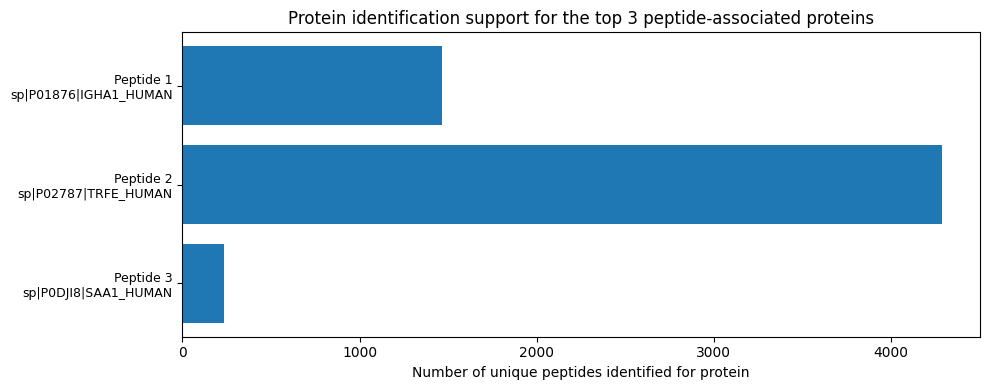

Saved: protein_identification_outputs_top3\top3_supporting_peptides_per_protein.png


In [10]:
plot_df = peptide_protein_table.dropna(subset=["main_protein"]).copy()
plot_df = plot_df.sort_values("rank")

labels = [
    f"Peptide {int(row['rank'])}\n{row['main_protein']}"
    for _, row in plot_df.iterrows()
]
values = plot_df["num_total_peptides_identified_for_protein"].fillna(0).astype(int).tolist()

fig, ax = plt.subplots(figsize=(10, max(4, 0.8 * len(plot_df))))
ax.barh(range(len(plot_df)), values)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of unique peptides identified for protein")
ax.set_title("Protein identification support for the top 3 peptide-associated proteins")
plt.tight_layout()

plot_path = OUTPUT_DIR / "top3_supporting_peptides_per_protein.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")

## Step 9 — Bipartite graph: top 3 peptides and associated proteins

This graph directly shows the relationship between the three selected peptides and their associated proteins.


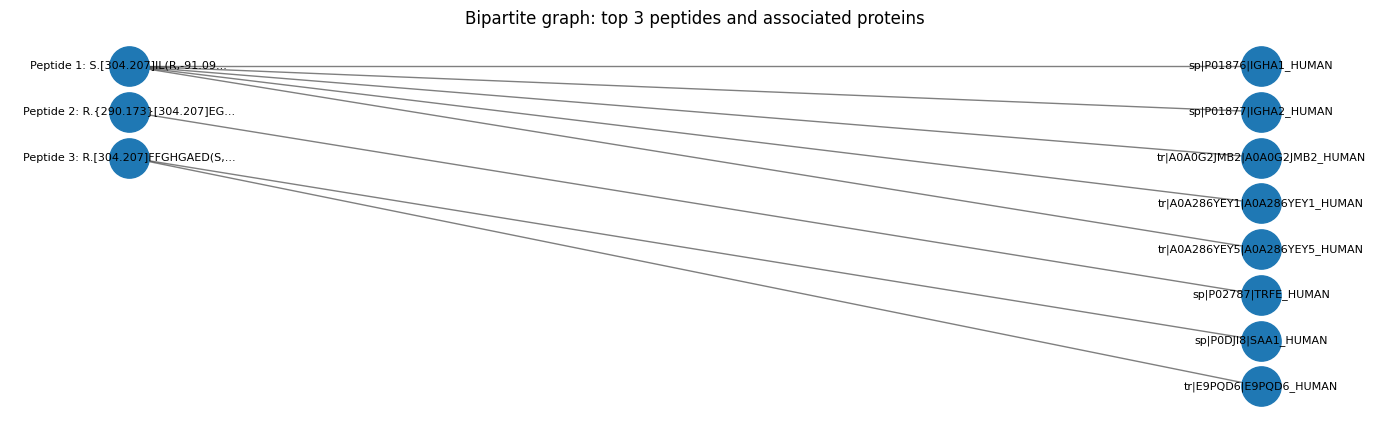

Saved: protein_identification_outputs_top3\top3_peptide_protein_bipartite_graph.png


In [11]:
if not HAS_NETWORKX:
    print("Skipping graph because networkx is not installed. Run `pip install networkx` if you want this figure.")
else:
    graph_rows = matched[["rank", "peptide", "mapped_proteins"]].copy()
    graph_rows = graph_rows.explode("mapped_proteins").dropna(subset=["mapped_proteins"])
    graph_rows = graph_rows[graph_rows["mapped_proteins"].astype(str).str.len() > 0]
    graph_rows = graph_rows.sort_values("rank")

    if graph_rows.empty:
        raise ValueError("No protein mappings found for the selected top 3 peptides.")

    G = nx.Graph()
    peptide_nodes = []
    protein_nodes = []

    for _, row in graph_rows.iterrows():
        pep_label = f"Peptide {int(row['rank'])}: {str(row['peptide'])[:22]}..."
        prot_label = str(row["mapped_proteins"])

        G.add_node(pep_label, bipartite="peptide")
        G.add_node(prot_label, bipartite="protein")
        G.add_edge(pep_label, prot_label)

        peptide_nodes.append(pep_label)
        protein_nodes.append(prot_label)

    peptide_nodes = list(dict.fromkeys(peptide_nodes))
    protein_nodes = list(dict.fromkeys(protein_nodes))

    pos = {}
    for i, node in enumerate(peptide_nodes):
        pos[node] = (0, -i)
    for i, node in enumerate(protein_nodes):
        pos[node] = (1, -i)

    fig_height = max(4, 0.55 * max(len(peptide_nodes), len(protein_nodes)))
    fig, ax = plt.subplots(figsize=(14, fig_height))

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, nodelist=peptide_nodes, node_size=800, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=protein_nodes, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

    ax.set_title("Bipartite graph: top 3 peptides and associated proteins")
    ax.axis("off")
    plt.tight_layout()

    graph_path = OUTPUT_DIR / "top3_peptide_protein_bipartite_graph.png"
    plt.savefig(graph_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {graph_path}")